In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import Sequential # type: ignore
from tensorflow.keras import layers # type: ignore
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.applications.resnet50 import ResNet50 # type: ignore
from tensorflow.keras.utils import image_dataset_from_directory # type: ignore
from tensorflow.keras.applications import VGG19 # type: ignore

In [2]:
# Constants
path = "dataset"
batch_size = 32
img_size = (224,224)
epochs = 12
categories = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
random_seed = 617

In [3]:
# Getting training data from given directory (80%)
train_data = image_dataset_from_directory(
    path,
    validation_split = 0.2,
    subset = "training",
    seed = random_seed,
    image_size = img_size,
    batch_size = batch_size,
    label_mode = 'categorical'
)

Found 4217 files belonging to 4 classes.
Using 3374 files for training.


In [4]:
# Getting validation data from given directory (20%)
val_data = image_dataset_from_directory(
    path,
    validation_split = 0.2,
    subset = "validation",
    seed = random_seed,
    image_size = img_size,
    batch_size = batch_size,
    label_mode = 'categorical'
)

Found 4217 files belonging to 4 classes.
Using 843 files for validation.


In [5]:
# Scaling all pixels between 0 and 1
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
# Augmenting some training data to make model more robust
# augmentation_layer = Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.1),
#     layers.RandomZoom(0.1),
# ])

# train_data = train_data.map(lambda x, y: (augmentation_layer(x, training=True), y))

In [7]:
# Get a base model and freeze its pretrained layers
base_model = VGG19(weights = "imagenet", input_shape = (224,224,3), include_top = False)

for layer in base_model.layers:
    layer.trainable = False

In [8]:
# Build a new model on top of base model
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.1)(x)
output = layers.Dense(len(categories), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, validation_data=val_data, epochs=epochs)

Epoch 1/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.4185 - loss: 1.2151 - val_accuracy: 0.5931 - val_loss: 0.9003
Epoch 2/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6147 - loss: 0.8924 - val_accuracy: 0.7023 - val_loss: 0.7393
Epoch 3/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.6838 - loss: 0.7502 - val_accuracy: 0.7651 - val_loss: 0.6254
Epoch 4/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.7087 - loss: 0.7002 - val_accuracy: 0.7888 - val_loss: 0.5552
Epoch 5/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.7291 - loss: 0.6707 - val_accuracy: 0.7473 - val_loss: 0.5926
Epoch 6/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.7484 - loss: 0.6176 - val_accuracy: 0.7972 - val_loss: 0.4959
Epoch 7/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.7626 - loss: 0.5787 - val_accuracy: 0.7794 - val_loss: 0.4985
Epoch 8/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.7656 - loss: 0.5726 - val_accu

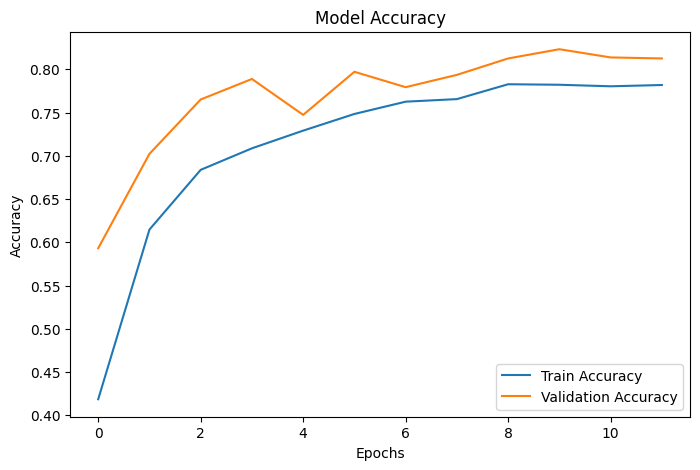

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [12]:
model.save("model.keras")

In [16]:
from tensorflow.keras.models import load_model # type: ignore
from tensorflow.keras.utils import load_img, img_to_array # type: ignore

In [17]:
up_model = load_model("model.keras")

In [22]:
img = load_img('dataset/cataract/_0_4015166.jpg', target_size=(224, 224))
img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [24]:
categories = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
predictions = up_model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_label = categories[predicted_index]
predicted_prob = predictions[0][predicted_index]

print(f"Predicted class: {predicted_label} with confidence {predicted_prob:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Predicted class: cataract with confidence 0.91
